### Lab-4

In [23]:
import torch 
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, balanced_accuracy_score
from sklearn.utils import resample
import numpy as np

In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
device

device(type='cuda')

In [3]:
# Penumonia

In [35]:
import matplotlib.pyplot as plt

def Plot_History(results, metric="loss"):

    for key in results:
        plt.plot(results[key][metric].keys(), results[key][metric].keys(), label=key)
    
    plt.xlabel("Epochs")
    plt.ylabel(metric)
    plt.legend()
    plt.title(metric)
    plt.show()

In [4]:
def Calculate_Norm(loader: DataLoader):
    mean = 0
    std = 0
    total_images = 0
    
    for images, _ in loader:
        batch_samples = images.size(0)  # Get the batch size
        images = images.view(batch_samples, images.size(1), -1)  # Flatten the image
        mean += images.mean(2).sum(0)  # Calculate mean
        std += images.std(2).sum(0)  # Calculate std
        total_images += batch_samples

    mean /= total_images
    std /= total_images

    return mean, std

In [5]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

def Set_Loader(source: str, batch_size: int, shape: tuple = (224, 224), isTorchDataset: bool = False, isGrayScale=False, Normalize: bool = False, shuffle: bool = True):
    s0, s1 = shape
    trans = [transforms.Resize((s0, s1)), transforms.ToTensor()]

    if isGrayScale:
        trans.append(transforms.Grayscale(num_output_channels=3))

    base_transform = transforms.Compose(trans)

    if isTorchDataset:
        train_dataset = getattr(datasets, source)(root='./data', train=True, download=True, transform=base_transform)
        test_dataset = getattr(datasets, source)(root='./data', train=False, download=True, transform=base_transform)
    else:
        # Custom dataset using ImageFolder
        train_path = os.path.join(source, 'train')
        test_path = os.path.join(source, 'test')
        
        # Ensure that both 'train' and 'test' folders exist
        if not os.path.exists(train_path) or not os.path.exists(test_path):
            raise ValueError(f"Expected 'train' and 'test' folders in {source}. Please check the dataset folder structure.")

        # Apply transformations to ImageFolder
        train_dataset = datasets.ImageFolder(root=train_path, transform=base_transform)
        test_dataset = datasets.ImageFolder(root=test_path, transform=base_transform)

    # Normalize if needed
    if Normalize:
        temp_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
        mean, std = Calculate_Norm(temp_loader)  # Assume Calculate_Norm is implemented elsewhere
        trans = [transforms.Resize((s0, s1)), transforms.ToTensor(), transforms.Normalize(mean=mean, std=std)]
        
        # Reapply grayscale conversion if needed
        if isGrayScale:
            trans.append(transforms.Grayscale(num_output_channels=3))  # Ensure grayscale has 3 channels for RGB

        norm_transform = transforms.Compose(trans)

        train_dataset.transform = norm_transform
        test_dataset.transform = norm_transform

    # DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=shuffle)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

In [6]:
class Model(nn.Module):
    def __init__(self, num_classes=2, Act_Func=nn.ReLU, drop=0.2):
        super(Model, self).__init__()
        
        self.Activation = Act_Func
        self.L1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            self.Activation(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.L2 = nn.Sequential(
            nn.Conv2d(16, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            self.Activation(),
            nn.MaxPool2d(2, 2)
        )

        self.L3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            self.Activation(),
            nn.MaxPool2d(2, 2)
        )

        self.L4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            self.Activation(),
            nn.MaxPool2d(2, 2)
        )

        # MODIFICATION: Added AdaptivePool so the model works for any input size (CIFAR/MNIST/Pneumonia)
        self.AdaptivePool = nn.AdaptiveAvgPool2d((7, 7)) 
        
        # MODIFICATION: Fixed input size to match the 7x7 adaptive output
        self.FC1 = nn.Linear(256 * 7 * 7, 512)
        self.FC2 = nn.Linear(512, num_classes)
        self.Fuction = nn.Dropout(drop)
        
    def forward(self, x):
        x = self.L1(x)
        x = self.L2(x)
        x = self.L3(x)
        x = self.L4(x)
        x = self.AdaptivePool(x) # Ensures spatial dimensions are 7x7 before flattening
        x = x.view(x.size(0), -1)
        x = self.FC1(x)
        x = self.Fuction(x)
        x = self.FC2(x)
        return x

The model is a custom Convolutional Neural Network composed of four convolutional blocks, each made up of a convolution layer, batch normalization, activation function, and max pooling. The convolution layers increases channel depth (16 → 256) to obtain more features hierarchically.

MaxPooling is used to reduce spatial dimensions and computational complexity while improving translation invariance. An Adaptive Average Pooling layer is applied before the fully connected layers to ensure a fixed 7×7 feature map size regardless of input image resolution, allowing the same architecture to generalize across datasets. Finally, two fully connected layers with dropout provide classification while reducing overfitting.

In [7]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        # MODIFICATION: Changed to handle both Binary and Multi-class targets automatically
        if logits.size(1) == 1:
            ce = F.binary_cross_entropy_with_logits(logits, targets.float(), reduction='none')
        else:
            ce = F.cross_entropy(logits, targets.long(), reduction='none')
            
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

In [8]:
def Trainer(epochs, criterion, optimizer, model, loader, Flatten=False):
    Loss, Accuracy = {}, {}
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    c = 0
    for epoch in range(epochs):
        print(epoch)
        Label_True, Label_Pred = [], []
        running_loss = 0.0
    
        for images, labels in loader:
            c += 1
            print(f"set #{c}")
            images, labels = images.to(device), labels.to(device)
            
            # MODIFICATION: Conditional label shaping for BCE vs CrossEntropy
            if isinstance(criterion, (nn.BCEWithLogitsLoss, FocalLoss)) and model.FC2.out_features == 1:
                labels_loss = labels.unsqueeze(1).float()
            else:
                labels_loss = labels.long()

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels_loss)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

            # MODIFICATION: Fixed Prediction logic for num_classes=1 (Binary)
            if outputs.size(1) == 1:
                preds = (torch.sigmoid(outputs) > 0.5).float()
            else:
                _, preds = torch.max(outputs, 1)

            Label_True.extend(labels.cpu().numpy())
            Label_Pred.extend(preds.detach().cpu().numpy())
        
        acc = accuracy_score(Label_True, Label_Pred)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(loader):.4f}, Accuracy: {acc:.4f}")
        Loss[epoch+1], Accuracy[epoch+1] = running_loss / len(loader), acc

    return Loss, Accuracy

In [9]:
def Tester(model, loader, Flatten=False):
    model.eval()
    Label_True = []
    Label_Pred = []
    
    with torch.no_grad():
        for images, labels in loader:
            if Flatten:
                images = images.view(images.size(0), -1)  # Flatten images if necessary
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            if outputs.size(1) == 1:
                preds = (torch.sigmoid(outputs) > 0.5).float()
            else:
                _, preds = torch.max(outputs, 1)
                
            Label_True.extend(labels.cpu().numpy())
            Label_Pred.extend(preds.detach().cpu().numpy())
    
    # Accuracy
    acc = accuracy_score(Label_True, Label_Pred)
    print(f"Accuracy: {acc:.4f}")
    
    f1_micro = f1_score(Label_True, Label_Pred, average='micro')
    f1_macro = f1_score(Label_True, Label_Pred, average='macro')
    print(f"F1 Score (Micro): {f1_micro:.4f}")
    print(f"F1 Score (Macro): {f1_macro:.4f}")
    
    precision_micro = precision_score(Label_True, Label_Pred, average='micro')
    precision_macro = precision_score(Label_True, Label_Pred, average='macro')
    print(f"Precision (Micro): {precision_micro:.4f}")
    print(f"Precision (Macro): {precision_macro:.4f}")
    
    recall_micro = recall_score(Label_True, Label_Pred, average='micro')
    recall_macro = recall_score(Label_True, Label_Pred, average='macro')
    print(f"Recall (Micro): {recall_micro:.4f}")
    print(f"Recall (Macro): {recall_macro:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(Label_True, Label_Pred)
    print("Confusion Matrix:")
    print(cm)

# Problem Statement 1: Architecture Design Focus
Design a custom CNN architecture or modify any standard CNN model to perform multi-class
image classification on your selected imbalanced datasets.

1. Justify the choice of architecture based on dataset characteristics
2. Decide the number of layers, filter sizes, kernel sizes, and activation functions
3. Implement appropriate regularization techniques (Dropout, Batch Normalization, L2)
4. Analyze the impact of dataset imbalance on classification performance

In [10]:
train_loader_CIFAR, test_loader_CIFAR = Set_Loader(source='CIFAR10', batch_size=16, shape=(224, 224), isTorchDataset=True, isGrayScale=False, Normalize=True)

In [13]:
M = Model(num_classes=10).to(device)
criterion = FocalLoss(gamma=2)
optimizer = optim.SGD(M.parameters(), lr=0.001, momentum=0.9)

In [14]:
Loss_History, Acc_History = Trainer(10, criterion, optimizer, M, train_loader_CIFAR)

0
set #1
set #2
set #3
set #4
set #5
set #6
set #7
set #8
set #9
set #10
set #11
set #12
set #13
set #14
set #15
set #16
set #17
set #18
set #19
set #20
set #21
set #22
set #23
set #24
set #25
set #26
set #27
set #28
set #29
set #30
set #31
set #32
set #33
set #34
set #35
set #36
set #37
set #38
set #39
set #40
set #41
set #42
set #43
set #44
set #45
set #46
set #47
set #48
set #49
set #50
set #51
set #52
set #53
set #54
set #55
set #56
set #57
set #58
set #59
set #60
set #61
set #62
set #63
set #64
set #65
set #66
set #67
set #68
set #69
set #70
set #71
set #72
set #73
set #74
set #75
set #76
set #77
set #78
set #79
set #80
set #81
set #82
set #83
set #84
set #85
set #86
set #87
set #88
set #89
set #90
set #91
set #92
set #93
set #94
set #95
set #96
set #97
set #98
set #99
set #100
set #101
set #102
set #103
set #104
set #105
set #106
set #107
set #108
set #109
set #110
set #111
set #112
set #113
set #114
set #115
set #116
set #117
set #118
set #119
set #120
set #121
set #122
set #123

In [24]:
Tester(M, test_loader_CIFAR, Flatten=False)

Accuracy: 0.7152
F1 Score (Micro): 0.7152
F1 Score (Macro): 0.7209
Precision (Micro): 0.7152
Precision (Macro): 0.7511
Recall (Micro): 0.7152
Recall (Macro): 0.7152
Confusion Matrix:
[[676   9  85  63  25   4  18  13  59  48]
 [ 25 717  15  36   3   2  16   5  20 161]
 [ 34   0 617 150  75  22  60  27   7   8]
 [  5   0  46 777  50  50  51  14   4   3]
 [ 14   1  52 119 708   8  46  46   5   1]
 [  6   0  46 385  45 472  16  25   2   3]
 [  3   0  31 114  22   7 818   3   1   1]
 [ 10   0  44  96  84  31   5 724   1   5]
 [ 57  16  12  60   9   3  18   3 771  51]
 [ 26  16   6  39   4   3   6  13  15 872]]


In [ ]:
train_loader_penumonia, test_loader_penumonia = Set_Loader(source='C:/Users/jodya/Desktop/Programmables/Sem-6/Deep Learning/Pneumonia Dataset/chest_xray', batch_size=16, shape=(224, 224), isTorchDataset=False, isGrayScale=True, Normalize=True)

In [28]:
M1 = Model(num_classes=1).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(M.parameters(), lr=0.01, momentum=0.9)

In [29]:
Pneumonia_Loss_History, Pneumonia_Acc_History = Trainer(10, criterion, optimizer, M1, train_loader_penumonia)

0
set #1
set #2
set #3
set #4
set #5
set #6
set #7
set #8
set #9
set #10
set #11
set #12
set #13
set #14
set #15
set #16
set #17
set #18
set #19
set #20
set #21
set #22
set #23
set #24
set #25
set #26
set #27
set #28
set #29
set #30
set #31
set #32
set #33
set #34
set #35
set #36
set #37
set #38
set #39
set #40
set #41
set #42
set #43
set #44
set #45
set #46
set #47
set #48
set #49
set #50
set #51
set #52
set #53
set #54
set #55
set #56
set #57
set #58
set #59
set #60
set #61
set #62
set #63
set #64
set #65
set #66
set #67
set #68
set #69
set #70
set #71
set #72
set #73
set #74
set #75
set #76
set #77
set #78
set #79
set #80
set #81
set #82
set #83
set #84
set #85
set #86
set #87
set #88
set #89
set #90
set #91
set #92
set #93
set #94
set #95
set #96
set #97
set #98
set #99
set #100
set #101
set #102
set #103
set #104
set #105
set #106
set #107
set #108
set #109
set #110
set #111
set #112
set #113
set #114
set #115
set #116
set #117
set #118
set #119
set #120
set #121
set #122
set #123

In [30]:
Tester(M1, test_loader_penumonia, Flatten=False)

Accuracy: 0.6250
F1 Score (Micro): 0.6250
F1 Score (Macro): 0.3846
Precision (Micro): 0.6250
Precision (Macro): 0.3125
Recall (Micro): 0.6250
Recall (Macro): 0.5000
Confusion Matrix:
[[  0 234]
 [  0 390]]


C:\venvs\torch_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# Problem Statement 2: Imbalanced Dataset Handling
The selected datasets are class-imbalanced. Design and implement strategies to handle imbalance:
Data-Level Techniques:
- Random Oversampling of minority classes
- Random Undersampling of majority classes
- SMOTE (Synthetic Minority Oversampling Technique) for image features
- Data augmentation specifically for minority classes (rotation, flip, zoom, color jitter)

Algorithm-Level Techniques:
- Class weighting in loss function
- Cost-sensitive learning
- Threshold adjustment during inference

Evaluate how these strategies affect:
- Training convergence and stability
- Class-wise accuracy, especially for minority classes
- Overall model performance (accuracy, macro/micro F1)

We're choosing random oversampling of all minority classes, with Class-weighting in the loss function

In [12]:
def random_oversample(train_loader, batch_size = 16):
    all_data = []
    all_labels = []
    
    for images, labels in train_loader:
        all_data.append(images)
        all_labels.append(labels)
    
    all_data = torch.cat(all_data, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    
    class_counts = torch.bincount(all_labels)
    max_class_size = class_counts.max().item()
    
    balanced_data = []
    balanced_labels = []

    for class_idx in range(len(class_counts)):
        class_data = all_data[all_labels == class_idx]
        class_labels = all_labels[all_labels == class_idx]
        
        # Oversample the current class to match the largest class size
        if len(class_data) < max_class_size:
            class_data, class_labels = resample(class_data, class_labels, replace=True, n_samples=max_class_size, random_state=42)
        
        balanced_data.append(class_data)
        balanced_labels.append(class_labels)
    
    balanced_data = torch.cat(balanced_data, dim=0)
    balanced_labels = torch.cat(balanced_labels, dim=0)
    
    # Rebuild DataLoader with oversampled data
    balanced_dataset = TensorDataset(balanced_data, balanced_labels)
    balanced_loader = DataLoader(balanced_dataset, batch_size=batch_size, shuffle=True)
    
    return balanced_loader

In [13]:
train_loader_penumonia_sampled = random_oversample(train_loader_penumonia , train_loader_penumonia.batch_size)

In [15]:
M1 = Model(num_classes=1).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(M1.parameters(), lr=0.01, momentum=0.9)

In [16]:
Loss_History, Acc_History = Trainer(10, criterion, optimizer, M1, train_loader_penumonia_sampled)

0
set #1
set #2
set #3
set #4
set #5
set #6
set #7
set #8
set #9
set #10
set #11
set #12
set #13
set #14
set #15
set #16
set #17
set #18
set #19
set #20
set #21
set #22
set #23
set #24
set #25
set #26
set #27
set #28
set #29
set #30
set #31
set #32
set #33
set #34
set #35
set #36
set #37
set #38
set #39
set #40
set #41
set #42
set #43
set #44
set #45
set #46
set #47
set #48
set #49
set #50
set #51
set #52
set #53
set #54
set #55
set #56
set #57
set #58
set #59
set #60
set #61
set #62
set #63
set #64
set #65
set #66
set #67
set #68
set #69
set #70
set #71
set #72
set #73
set #74
set #75
set #76
set #77
set #78
set #79
set #80
set #81
set #82
set #83
set #84
set #85
set #86
set #87
set #88
set #89
set #90
set #91
set #92
set #93
set #94
set #95
set #96
set #97
set #98
set #99
set #100
set #101
set #102
set #103
set #104
set #105
set #106
set #107
set #108
set #109
set #110
set #111
set #112
set #113
set #114
set #115
set #116
set #117
set #118
set #119
set #120
set #121
set #122
set #123

In [17]:
Tester(M1, test_loader_penumonia, Flatten=False)

Accuracy: 0.7196
F1 Score (Micro): 0.7196
F1 Score (Macro): 0.6116
Precision (Micro): 0.7196
Precision (Macro): 0.8373
Recall (Micro): 0.7196
Recall (Macro): 0.6269
Confusion Matrix:
[[ 60 174]
 [  1 389]]


In [19]:
del test_loader_penumonia, train_loader_penumonia_sampled

In [ ]:
train_loader_CIFAR_sampled = random_oversample(train_loader_CIFAR, train_loader_CIFAR.batch_size)

In [ ]:
M = Model(num_classes=10).to(device)
criterion = FocalLoss(gamma=2)
optimizer = optim.SGD(M.parameters(), lr=0.001, momentum=0.9)

In [ ]:
Loss_History, Acc_History = Trainer(10, criterion, optimizer, M, train_loader_CIFAR_sampled)

In [ ]:
Tester(M, test_loader_CIFAR, Flatten=False)

# Problem Statement 3: Comparative Architecture Analysis
Implement at least two different CNN architectures (e.g., EfficientNet vs ResNet, MobileNet vs VGG, or DenseNet vs Inception) on your selected imbalanced datasets.

Compare the models based on:
- Overall Accuracy and Top-k Accuracy
- Precision, Recall, F1-score (class-wise and macro-averaged)
- Confusion Matrix analysis
- Computational cost (FLOPs, parameters, inference time)
- ROC-AUC and PR-AUC curves
- Robustness to class imbalance (G-Mean, Balanced Accuracy)

In [15]:
train_loader_CIFAR, test_loader_CIFAR = Set_Loader(source='CIFAR10', batch_size=16, shape=(224, 224), isTorchDataset=True, isGrayScale=False, Normalize=True)

In [17]:
from torchvision import models
import torch.nn as nn

def Load_Model(name, num_classes=10):

    if name == "resnet":
        model = models.resnet18(pretrained=True)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif name == "efficientnet":
        model = models.efficientnet_b0(pretrained=True)
        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            num_classes
        )

    else:
        raise ValueError("Choose resnet or efficientnet")

    return model

In [18]:
ps3_models = ["resnet", "efficientnet"]
results_ps3 = {}

In [19]:
def Test_Model(model, loader):
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    
    y_true, y_pred, y_probs = [], [], []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())
    
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))
    print("F1 Macro:", f1_score(y_true, y_pred, average="macro"))
    print("Precision Macro:", precision_score(y_true, y_pred, average="macro"))
    print("Recall Macro:", recall_score(y_true, y_pred, average="macro"))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    
    return y_true, y_pred, y_probs

In [22]:
for model_name in ps3_models:
    model = Load_Model(model_name, num_classes=10)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    loss_hist, acc_hist = Trainer(
        epochs=10,
        criterion=criterion,
        optimizer=optimizer,
        model=model,
        loader=train_loader_CIFAR
    )

    print(f"\nTesting {model_name.upper()}")
    Test_Model(model, test_loader_CIFAR)

    results_ps3[model_name] = {
        "loss": loss_hist,
        "acc": acc_hist
    }

    # IMPORTANT: DELETE MODEL
    del model
    torch.cuda.empty_cache()
    gc.collect()

0
set #1
set #2
set #3
set #4
set #5
set #6
set #7
set #8
set #9
set #10
set #11
set #12
set #13
set #14
set #15
set #16
set #17
set #18
set #19
set #20
set #21
set #22
set #23
set #24
set #25
set #26
set #27
set #28
set #29
set #30
set #31
set #32
set #33
set #34
set #35
set #36
set #37
set #38
set #39
set #40
set #41
set #42
set #43
set #44
set #45
set #46
set #47
set #48
set #49
set #50
set #51
set #52
set #53
set #54
set #55
set #56
set #57
set #58
set #59
set #60
set #61
set #62
set #63
set #64
set #65
set #66
set #67
set #68
set #69
set #70
set #71
set #72
set #73
set #74
set #75
set #76
set #77
set #78
set #79
set #80
set #81
set #82
set #83
set #84
set #85
set #86
set #87
set #88
set #89
set #90
set #91
set #92
set #93
set #94
set #95
set #96
set #97
set #98
set #99
set #100
set #101
set #102
set #103
set #104
set #105
set #106
set #107
set #108
set #109
set #110
set #111
set #112
set #113
set #114
set #115
set #116
set #117
set #118
set #119
set #120
set #121
set #122
set #123

NameError: name 'balanced_accuracy_score' is not defined

In [25]:
# The test of the ResNET

Accuracy: 0.9309
Balanced Accuracy: 0.9309
F1 Macro: 0.9309963042390071
Precision Macro: 0.9315112694647212
Recall Macro: 0.9309
Confusion Matrix:
 [[907   2  45   8   4   0   3   3  23   5]
 [  4 946   1   0   1   0   1   2   2  43]
 [  2   0 917  25  19  12  18   5   1   1]
 [  0   0  13 879  14  60  20   7   3   4]
 [  0   0   3  11 954   7  10  15   0   0]
 [  2   0  10  71  11 887   7  11   0   1]
 [  1   0   9  15  11   6 958   0   0   0]
 [  1   0   6  10  12  16   1 953   0   1]
 [ 19   6   4   2   0   0   3   1 942  23]
 [  8  13   2   6   0   0   0   0   5 966]]


1915

In [28]:
model_name = 'efficientnet'
model = Load_Model(model_name, num_classes=10)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

loss_hist, acc_hist = Trainer(
        epochs=10,
        criterion=criterion,
        optimizer=optimizer,
        model=model,
        loader=train_loader_CIFAR
    )
print(f"\nTesting {model_name.upper()}")
Test_Model(model, test_loader_CIFAR)

results_ps3[model_name] = {
        "loss": loss_hist,
        "acc": acc_hist
}

    # IMPORTANT: DELETE MODEL
del model
torch.cuda.empty_cache()
gc.collect()

C:\venvs\torch_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\venvs\torch_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\jodya/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|█████████████████████████████████████████████████████████████████████████████| 20.5M/20.5M [00:02<00:00, 8.18MB/s]


0
set #1
set #2
set #3
set #4
set #5
set #6
set #7
set #8
set #9
set #10
set #11
set #12
set #13
set #14
set #15
set #16
set #17
set #18
set #19
set #20
set #21
set #22
set #23
set #24
set #25
set #26
set #27
set #28
set #29
set #30
set #31
set #32
set #33
set #34
set #35
set #36
set #37
set #38
set #39
set #40
set #41
set #42
set #43
set #44
set #45
set #46
set #47
set #48
set #49
set #50
set #51
set #52
set #53
set #54
set #55
set #56
set #57
set #58
set #59
set #60
set #61
set #62
set #63
set #64
set #65
set #66
set #67
set #68
set #69
set #70
set #71
set #72
set #73
set #74
set #75
set #76
set #77
set #78
set #79
set #80
set #81
set #82
set #83
set #84
set #85
set #86
set #87
set #88
set #89
set #90
set #91
set #92
set #93
set #94
set #95
set #96
set #97
set #98
set #99
set #100
set #101
set #102
set #103
set #104
set #105
set #106
set #107
set #108
set #109
set #110
set #111
set #112
set #113
set #114
set #115
set #116
set #117
set #118
set #119
set #120
set #121
set #122
set #123

22

# Problem Statement 4: Loss Function & Optimization Challenge

Investigate the effect of different loss functions and optimizers on imbalanced datasets.
Loss Functions to Experiment:
- Cross-Entropy Loss (baseline)
- Weighted Cross-Entropy Loss
- Focal Loss (with different gamma values: 0.5, 1, 2, 5)
- Class-Balanced Loss
- Label Smoothing Cross-Entropy
Optimizers to Experiment:
- SGD (with and without momentum)
- Adam
- AdamW (Adam with weight decay)
- RMSProp
  
Analyze:
- Convergence speed and training curves
- Minority class recognition improvement
- Overfitting behavior and generalization
- Impact of learning rate scheduling

In [29]:
loss_list = [
    ("CrossEntropy", nn.CrossEntropyLoss()),
    ("LabelSmoothing", nn.CrossEntropyLoss(label_smoothing=0.1)),
    ("Focal_0.5", FocalLoss(gamma=0.5)),
    ("Focal_1", FocalLoss(gamma=1)),
    ("Focal_2", FocalLoss(gamma=2)),
    ("Focal_5", FocalLoss(gamma=5))
]

In [30]:
optimizer_list = [
    ("SGD", lambda model: torch.optim.SGD(model.parameters(), lr=1e-3)),
    ("SGD_Momentum", lambda model: torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)),
    ("Adam", lambda model: torch.optim.Adam(model.parameters(), lr=1e-3)),
    ("AdamW", lambda model: torch.optim.AdamW(model.parameters(), lr=1e-3)),
    ("RMSProp", lambda model: torch.optim.RMSprop(model.parameters(), lr=1e-3))
]

### Cross Entropy

$$
\mathcal{L}_{CE} = - \sum_{i=1}^{C} y_i \log(p_i)
$$
$$
p_i = \frac{e^{z_i}}{\sum_{j=1}^{C} e^{z_j}}
$$

### Label Smoothing & Weighted CE

$$\mathcal{L}_{WCE} = - \sum_{i=1}^{C} w_i y_i \log(p_i)$$
 $$ Where, w_i = \frac{1}{n_i}$$

$$ y_i^{LS} =
\begin{cases}
1 - \epsilon & \text{if correct class} \\
\frac{\epsilon}{C-1} & \text{otherwise}
\end{cases} $$

### Focal Loss

$$ \mathcal{L}_{FL} = - (1 - p_t)^{\gamma} \log(p_t) $$
$$
p_t =
\begin{cases}
p & \text{if } y=1 \\
1-p & \text{if } y=0
\end{cases}
$$

In [ ]:
import gc

fixed_optimizer = ("Adam", lambda model: torch.optim.Adam(model.parameters(), lr=1e-3))
for loss_name, loss_fn in loss_list:

    print(f"\nTraining with Loss: {loss_name}")
    results = {}
    model = Model(num_classes=10).to(device)
    optimizer = fixed_optimizer[1](model)

    loss_hist, acc_hist = Trainer(
        epochs=2,
        criterion=loss_fn,
        optimizer=optimizer,
        model=model,
        loader=train_loader_CIFAR
    )

    results[loss_name] = {
    "loss": loss_hist,
    "acc": acc_hist
    }
    Plot_History(results, metric="loss")
    Plot_History(results, metric="acc")

    print("Testing...")
    Tester(model, test_loader_CIFAR)

    del model
    torch.cuda.empty_cache()
    gc.collect()

Worst: Focal loss at 0.5, due to equal attenuating rather than exponentializing the loss for incorrectly classified items.

Cross Entropy: For some reason, standard Cross Entropy has done 'well', but it is to be noted that Focal loss, and the like take time to show their effectiveness

### Stochastic Gradient Descent

$$ \theta_{t+1} = \theta_t - \eta \nabla_{\theta} \mathcal{L} $$

### SGD with Momentum

$$ v_{t+1} = \beta v_t + \nabla_{\theta} \mathcal{L} $$
$$ \theta_{t+1} = \theta_t - \eta v_{t+1} $$

### Adam 

$$ m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t $$
$$ v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$ 
$$ \hat{m}_t = \frac{m_t}{1-\beta_1^t}, \hat{v}_t = \frac{v_t}{1-\beta_2^t} $$
$$ \theta_{t+1} = \theta_t - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} $$

### Adam with Weight Decay

$$ \theta_{t+1} =
\theta_t - \eta
\left(
\frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
+ \lambda \theta_t
\right)
$$


### RMS Prop


$$v_t = \beta v_{t-1} + (1-\beta) g_t^2$$
$$ \theta_{t+1} = \theta_t - \eta \frac{g_t}{\sqrt{v_t} + \epsilon} $$



Training with Optimizer: SGD
0
set #1
set #2
set #3
set #4
set #5
set #6
set #7
set #8
set #9
set #10
set #11
set #12
set #13
set #14
set #15
set #16
set #17
set #18
set #19
set #20
set #21
set #22
set #23
set #24
set #25
set #26
set #27
set #28
set #29
set #30
set #31
set #32
set #33
set #34
set #35
set #36
set #37
set #38
set #39
set #40
set #41
set #42
set #43
set #44
set #45
set #46
set #47
set #48
set #49
set #50
set #51
set #52
set #53
set #54
set #55
set #56
set #57
set #58
set #59
set #60
set #61
set #62
set #63
set #64
set #65
set #66
set #67
set #68
set #69
set #70
set #71
set #72
set #73
set #74
set #75
set #76
set #77
set #78
set #79
set #80
set #81
set #82
set #83
set #84
set #85
set #86
set #87
set #88
set #89
set #90
set #91
set #92
set #93
set #94
set #95
set #96
set #97
set #98
set #99
set #100
set #101
set #102
set #103
set #104
set #105
set #106
set #107
set #108
set #109
set #110
set #111
set #112
set #113
set #114
set #115
set #116
set #117
set #118
set #119
set #

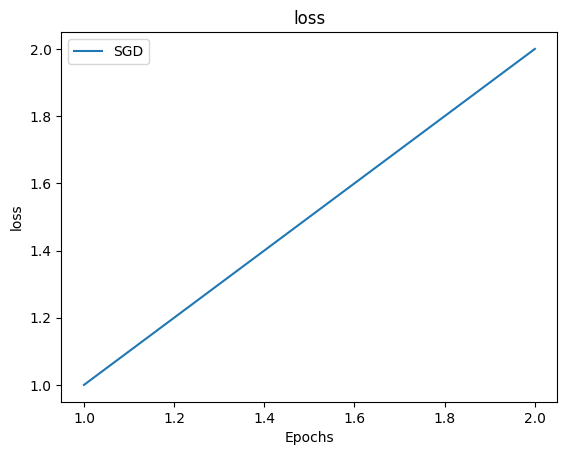

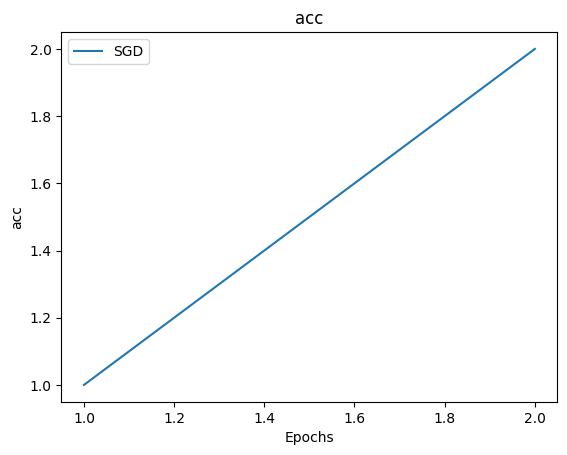

Testing...
Accuracy: 0.5963
F1 Score (Micro): 0.5963
F1 Score (Macro): 0.5995
Precision (Micro): 0.5963
Precision (Macro): 0.6196
Recall (Micro): 0.5963
Recall (Macro): 0.5963
Confusion Matrix:
[[658  18  44  52  24  38  14  26  81  45]
 [ 31 697   7  28  16  16  15  22  28 140]
 [ 75   4 339 118 147 184  64  51  13   5]
 [ 11   2  34 416  94 353  49  31   3   7]
 [ 23   1  93  93 513 127  68  76   3   3]
 [  9   3  16 132  62 728  10  36   2   2]
 [  4   6  41 125  93  62 644  18   3   4]
 [ 12   2  16  54  65 169   8 662   2  10]
 [128  46  10  40  21  32  12  14 655  42]
 [ 53  90   8  45  18  31  20  61  23 651]]

Training with Optimizer: SGD_Momentum
0
set #1
set #2
set #3
set #4
set #5
set #6
set #7
set #8
set #9
set #10
set #11
set #12
set #13
set #14
set #15
set #16
set #17
set #18
set #19
set #20
set #21
set #22
set #23
set #24
set #25
set #26
set #27
set #28
set #29
set #30
set #31
set #32
set #33
set #34
set #35
set #36
set #37
set #38
set #39
set #40
set #41
set #42
set #43

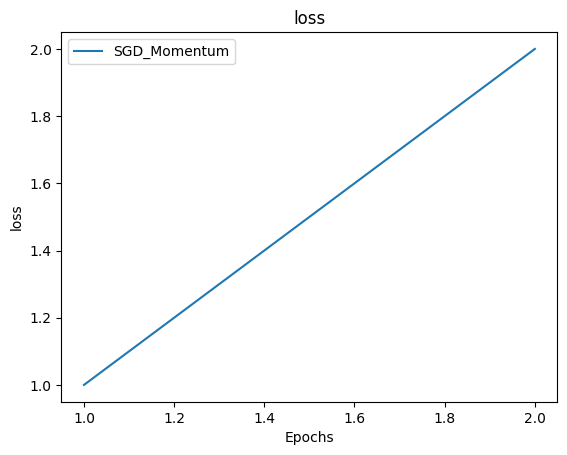

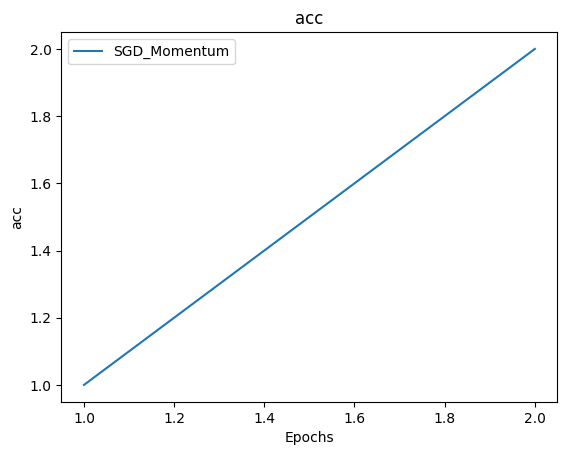

Testing...
Accuracy: 0.6565
F1 Score (Micro): 0.6565
F1 Score (Macro): 0.6601
Precision (Micro): 0.6565
Precision (Macro): 0.6723
Recall (Micro): 0.6565
Recall (Macro): 0.6565
Confusion Matrix:
[[702  10  92  52  28  13  13  26  38  26]
 [ 38 745  13  38  11  15  24  15  22  79]
 [ 52   2 535  71 110 107  82  35   3   3]
 [  6   3  67 498  49 275  61  31   4   6]
 [ 18   0  89  77 549  84  89  86   8   0]
 [  9   0  66 139  39 682  17  44   3   1]
 [  3   1  33  99  36  46 777   4   1   0]
 [ 10   0  37  39  51 111   7 744   1   0]
 [169  39  23  31  11  15  11  13 666  22]
 [ 43  99  14  47   8  21  13  61  27 667]]

Training with Optimizer: Adam
0
set #1
set #2
set #3
set #4
set #5
set #6
set #7
set #8
set #9
set #10
set #11
set #12
set #13
set #14
set #15
set #16
set #17
set #18
set #19
set #20
set #21
set #22
set #23
set #24
set #25
set #26
set #27
set #28
set #29
set #30
set #31
set #32
set #33
set #34
set #35
set #36
set #37
set #38
set #39
set #40
set #41
set #42
set #43
set #44

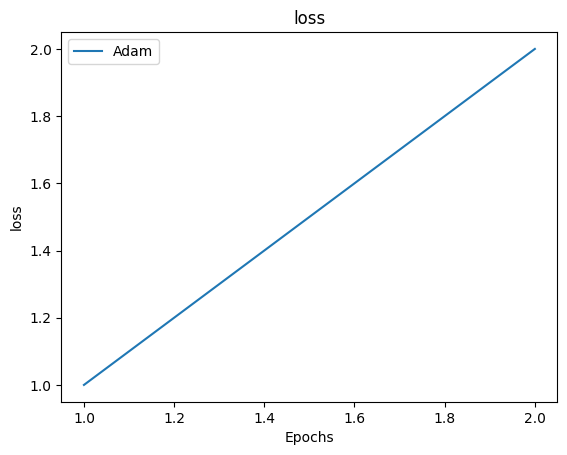

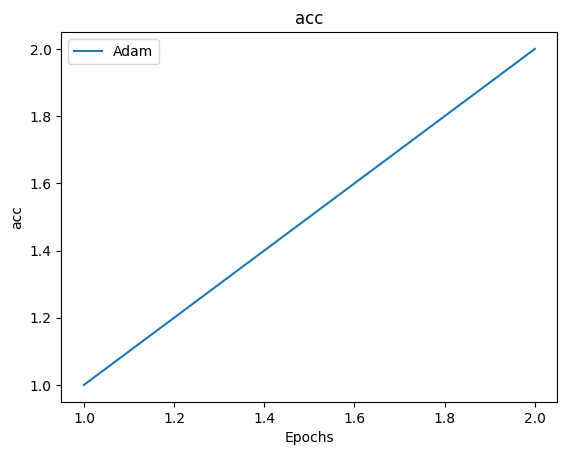

Testing...
Accuracy: 0.6668
F1 Score (Micro): 0.6668
F1 Score (Macro): 0.6648
Precision (Micro): 0.6668
Precision (Macro): 0.6743
Recall (Micro): 0.6668
Recall (Macro): 0.6668
Confusion Matrix:
[[712  30  32  25  36   5   8  18  55  79]
 [ 17 818   0   8   5   5   5   2  28 112]
 [ 82  13 424  72 193  79  43  59   9  26]
 [ 20  28  47 507 118 150  50  41  12  27]
 [ 22   7  37  62 702  22  39  93   8   8]
 [ 12  14  38 191  89 565   9  54  10  18]
 [  8  15  42  83 108  15 698  10   8  13]
 [ 13   9  19  47  83  53   3 731   2  40]
 [150  60   8  14  11   6   3   9 685  54]
 [ 17 100   4   9   3   6   4   9  22 826]]

Training with Optimizer: AdamW
0
set #1
set #2
set #3
set #4
set #5
set #6
set #7
set #8
set #9
set #10
set #11
set #12
set #13
set #14
set #15
set #16
set #17
set #18
set #19
set #20
set #21
set #22
set #23
set #24
set #25
set #26
set #27
set #28
set #29
set #30
set #31
set #32
set #33
set #34
set #35
set #36
set #37
set #38
set #39
set #40
set #41
set #42
set #43
set #4

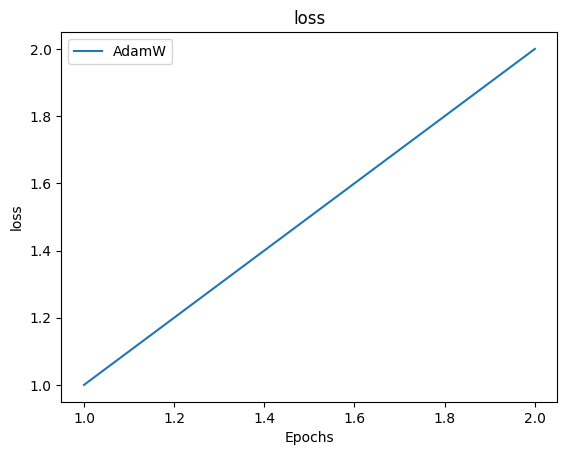

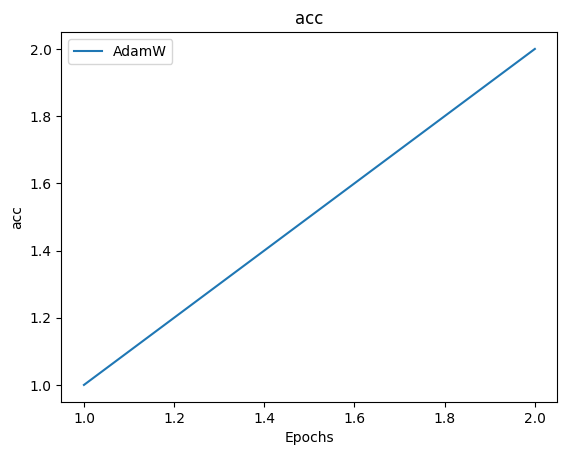

Testing...
Accuracy: 0.6676
F1 Score (Micro): 0.6676
F1 Score (Macro): 0.6652
Precision (Micro): 0.6676
Precision (Macro): 0.6742
Recall (Micro): 0.6676
Recall (Macro): 0.6676
Confusion Matrix:
[[752  30  55  13  20   4   6  19  40  61]
 [ 23 766   9   4   5   1   6  10  29 147]
 [ 80   4 478  44 182  74  45  65   9  19]
 [ 45  10  58 449 125 143  50  68  13  39]
 [ 32   3  67  45 718  23  25  74   8   5]
 [ 28   7  42 150  83 534  11 107  13  25]
 [ 11   4  48  74 129  23 672  11  13  15]
 [ 14   2  29  25  81  38   2 793   0  16]
 [166  57  12   7   9   5   3   5 701  35]
 [ 29  70   9   8  16   2   3  23  27 813]]

Training with Optimizer: RMSProp
0
set #1
set #2
set #3
set #4
set #5
set #6
set #7
set #8
set #9
set #10
set #11
set #12
set #13
set #14
set #15
set #16
set #17
set #18
set #19
set #20
set #21
set #22
set #23
set #24
set #25
set #26
set #27
set #28
set #29
set #30
set #31
set #32
set #33
set #34
set #35
set #36
set #37
set #38
set #39
set #40
set #41
set #42
set #43
set 

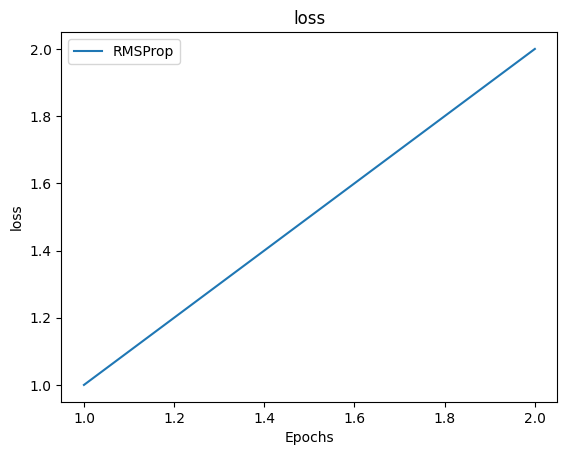

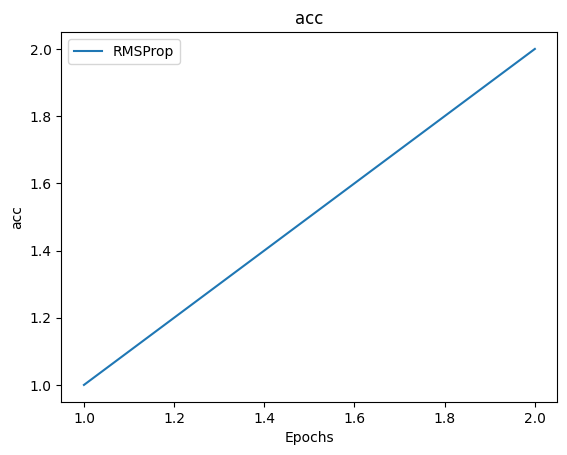

Testing...
Accuracy: 0.6178
F1 Score (Micro): 0.6178
F1 Score (Macro): 0.6129
Precision (Micro): 0.6178
Precision (Macro): 0.6325
Recall (Micro): 0.6178
Recall (Macro): 0.6178
Confusion Matrix:
[[767  18  22  14  16   3  15   3 105  37]
 [ 51 720   8   8   7   4  19   7  70 106]
 [130   1 351  52 176  44 183  18  35  10]
 [ 56  14  72 397 148 115 121  15  49  13]
 [ 46   2  47  56 637  10 166  18  15   3]
 [ 34   5  79 181 136 445  36  38  35  11]
 [ 11   6  25  73  44  12 817   1   7   4]
 [ 38   2  38  47 221  46  16 566  12  14]
 [141  32   9   7   7   3  13   2 766  20]
 [ 60  93   9  15  13   4  11   8  75 712]]


In [39]:
fixed_loss = ("CrossEntropy", nn.CrossEntropyLoss())
for opt_name, opt_fn in optimizer_list:

    print(f"\nTraining with Optimizer: {opt_name}")
    results = {}
    model = Model(num_classes=10).to(device)
    optimizer = opt_fn(model)

    loss_hist, acc_hist = Trainer(
        epochs=2,
        criterion=fixed_loss[1],
        optimizer=optimizer,
        model=model,
        loader=train_loader_CIFAR
    )
    results[opt_name] = {
    "loss": loss_hist,
    "acc": acc_hist
    }
    Plot_History(results, metric="loss")
    Plot_History(results, metric="acc")

    print("Testing...")
    Tester(model, test_loader_CIFAR)

    del model
    torch.cuda.empty_cache()
    gc.collect()

In [40]:
def Extract_Features(model, loader):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    features, labels_all = [], []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            x = model.forward(images)
            
            features.append(x.cpu())
            labels_all.append(labels)
            
    return torch.cat(features), torch.cat(labels_all)

In [41]:
from sklearn.manifold import TSNE

def Plot_TSNE(features, labels):
    tsne = TSNE(n_components=2, random_state=42)
    reduced = tsne.fit_transform(features)
    
    plt.scatter(reduced[:,0], reduced[:,1], c=labels, cmap='tab10')
    plt.title("t-SNE")
    plt.show()

In [49]:
import umap

def Plot_UMAP(features, labels):
    reducer = umap.UMAP()
    reduced = reducer.fit_transform(features)
    
    plt.scatter(reduced[:,0], reduced[:,1], c=labels, cmap='tab10')
    plt.title("UMAP")
    plt.show()

In [44]:
M = Model(num_classes=10).to(device)
criterion = FocalLoss(gamma=2)
optimizer = optim.SGD(M.parameters(), lr=0.001, momentum=0.9)

In [45]:
Loss_History, Acc_History = Trainer(5, criterion, optimizer, M, train_loader_CIFAR)

0
set #1
set #2
set #3
set #4
set #5
set #6
set #7
set #8
set #9
set #10
set #11
set #12
set #13
set #14
set #15
set #16
set #17
set #18
set #19
set #20
set #21
set #22
set #23
set #24
set #25
set #26
set #27
set #28
set #29
set #30
set #31
set #32
set #33
set #34
set #35
set #36
set #37
set #38
set #39
set #40
set #41
set #42
set #43
set #44
set #45
set #46
set #47
set #48
set #49
set #50
set #51
set #52
set #53
set #54
set #55
set #56
set #57
set #58
set #59
set #60
set #61
set #62
set #63
set #64
set #65
set #66
set #67
set #68
set #69
set #70
set #71
set #72
set #73
set #74
set #75
set #76
set #77
set #78
set #79
set #80
set #81
set #82
set #83
set #84
set #85
set #86
set #87
set #88
set #89
set #90
set #91
set #92
set #93
set #94
set #95
set #96
set #97
set #98
set #99
set #100
set #101
set #102
set #103
set #104
set #105
set #106
set #107
set #108
set #109
set #110
set #111
set #112
set #113
set #114
set #115
set #116
set #117
set #118
set #119
set #120
set #121
set #122
set #123

In [47]:
Ex_features, Ex_labels = Extract_Features(M, test_loader_CIFAR)

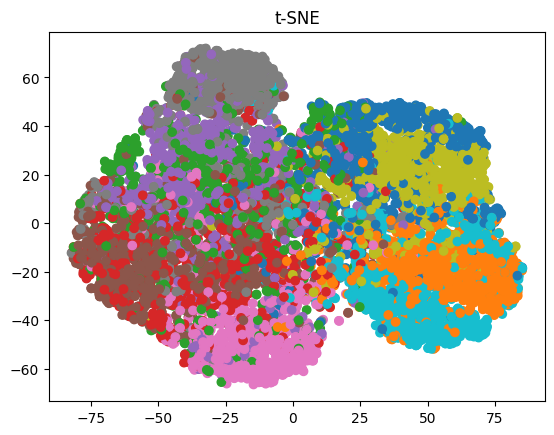

In [48]:
Plot_TSNE(Ex_features, Ex_labels)

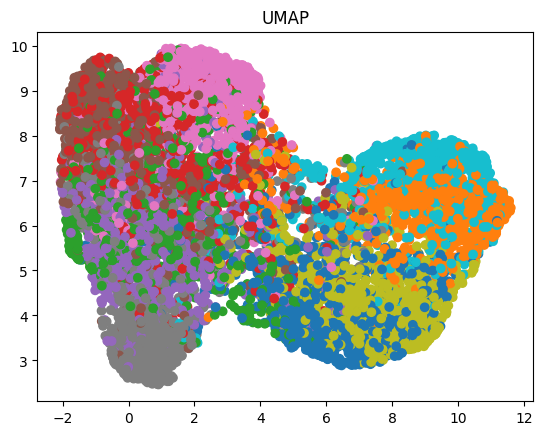

In [50]:
Plot_UMAP(Ex_features, Ex_labels)

# Problem Statement 6: Generalization & Transfer Learning Test
Train the CNN model on one imbalanced dataset and test its transferability on another related dataset.

Analyze:
- Transferability of learned features
- Performance degradation across domains
- Fine-tuning vs feature extraction approaches
- Impact of dataset complexity and domain shift

In [56]:
train_loader_flower, test_loader_flower = Set_Loader("C:/Users/jodya/Desktop/Programmables/Sem-6/Deep Learning/flowers", batch_size=16)
train_dataset = train_loader_flower.dataset
train_size = int(0.8 * len(train_dataset))
test_size = len(train_dataset) - train_size
train_subset, test_subset = torch.utils.data.random_split(train_dataset, [train_size, test_size])
train_loader_flower = torch.utils.data.DataLoader(train_subset, batch_size=16, shuffle=True)
test_loader_flower = torch.utils.data.DataLoader(test_subset, batch_size=16, shuffle=False)

for param in M.parameters():
    param.requires_grad = False

# Unfreeze the fully connected layers
for param in M.FC1.parameters():
    param.requires_grad = True

for param in M.FC2.parameters():
    param.requires_grad = True

criterion = FocalLoss(gamma=2)
optimizer = optim.SGD(filter(lambda p: p.requires_grad, M.parameters()), lr=0.001, momentum=0.9)

loss_hist, acc_hist = Trainer(epochs=10,criterion=criterion, optimizer=optimizer, model=M, loader=train_loader_flower)
Tester(M, test_loader)

0
set #1
set #2
set #3
set #4
set #5
set #6
set #7
set #8
set #9
set #10
set #11
set #12
set #13
set #14
set #15
set #16
set #17
set #18
set #19
set #20
set #21
set #22
set #23
set #24
set #25
set #26
set #27
set #28
set #29
set #30
set #31
set #32
set #33
set #34
set #35
set #36
set #37
set #38
set #39
set #40
set #41
set #42
set #43
set #44
set #45
set #46
set #47
set #48
set #49
set #50
set #51
set #52
set #53
set #54
set #55
set #56
set #57
set #58
set #59
set #60
set #61
set #62
set #63
set #64
set #65
set #66
set #67
set #68
set #69
set #70
set #71
set #72
set #73
set #74
set #75
set #76
set #77
set #78
set #79
set #80
set #81
set #82
set #83
set #84
set #85
set #86
set #87
set #88
set #89
set #90
set #91
set #92
set #93
set #94
set #95
set #96
set #97
set #98
set #99
set #100
set #101
set #102
set #103
set #104
set #105
set #106
set #107
set #108
set #109
set #110
set #111
set #112
set #113
set #114
set #115
set #116
set #117
set #118
set #119
set #120
set #121
set #122
set #123

NameError: name 'test_loader' is not defined

In [57]:
Tester(M, test_loader_flower)

Accuracy: 0.6343
F1 Score (Micro): 0.6343
F1 Score (Macro): 0.6266
Precision (Micro): 0.6343
Precision (Macro): 0.6593
Recall (Micro): 0.6343
Recall (Macro): 0.6414
Confusion Matrix:
[[110  27  15   7   2]
 [ 20 156   2  19   1]
 [ 26  17 125   2   7]
 [ 14  18   9  80   1]
 [ 27  20  60  22  77]]


# Problem Statement 7: Error Analysis & Improvement Proposals
For incorrectly classified samples, perform detailed failure analysis:
• Identify which classes fail most frequently
• Analyze confusion patterns between similar classes
• Correlate errors with class imbalance ratios
• Visualize misclassified samples

In our model, for CIFAR, we find taht the worst classified item was the dog, and the best classified item was truck and frog classes. It could be due to the fact of similarity to the cat class, which can be seen where a large sample of dog class items were misclassified as cat. For some reason, birds were misclassified with cat and deer to a large degree. Similarly Automibile to trucks and Airplane with Ships.

The correlation could be correalted to imbalance ratio, often alluding certain principles to one class rather than the other, but it could also be due to the similarity of it all. 

Our macro F1 (0.7209) is lower than micro because of dog class.

The problem with our model, we're findign that initially, the model is only classifying Penumonia over Normal. The dataset is highly imbalanced, so terribly so that, it has better chances of getting the right chance provided we just say one optino over the other. A better 